# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

df = pd.read_csv(r'C:\Users\spoll\Desktop\Full Sail\Data Viz\Data_Visualization_And_Modeling_Online\Lab\Employee_productivity.csv')
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


R² for YearsAtCompany vs Productivity:


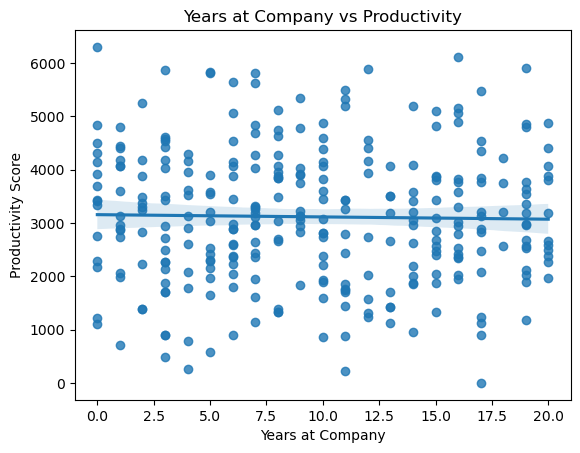

R² for YearsAtCompany: 0.0004


In [21]:
sns.regplot(data=df, x='YearsAtCompany', y='ProductivityScore')
plt.title('Years at Company vs Productivity')
plt.xlabel('Years at Company')
plt.ylabel('Productivity Score')
plt.show()

r2_years = r2_score(df['ProductivityScore'], 
                    LinearRegression().fit(df[['YearsAtCompany']], 
                    df['ProductivityScore']).predict(df[['YearsAtCompany']]))
print(f'R² for YearsAtCompany: {r2_years:.4f}')

R² for HoursWorked vs Productivity:

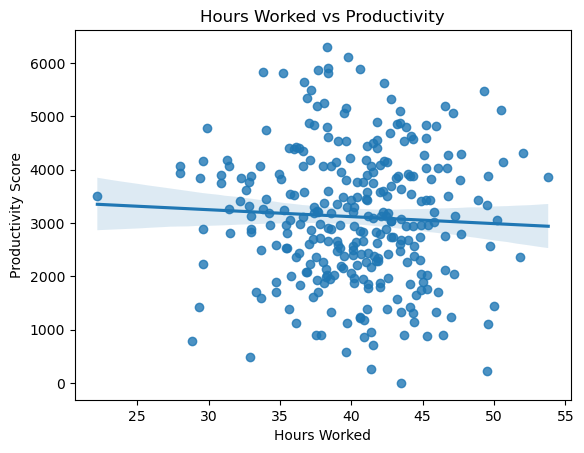

R² for HoursWorked: 0.0026


In [22]:
sns.regplot(data=df, x='HoursWorked', y='ProductivityScore')
plt.title('Hours Worked vs Productivity')
plt.xlabel('Hours Worked')
plt.ylabel('Productivity Score')
plt.show()

r2_hours = r2_score(df['ProductivityScore'], 
                    LinearRegression().fit(df[['HoursWorked']], 
                    df['ProductivityScore']).predict(df[['HoursWorked']]))
print(f'R² for HoursWorked: {r2_hours:.4f}')

R² for FocusScore vs Productivity:

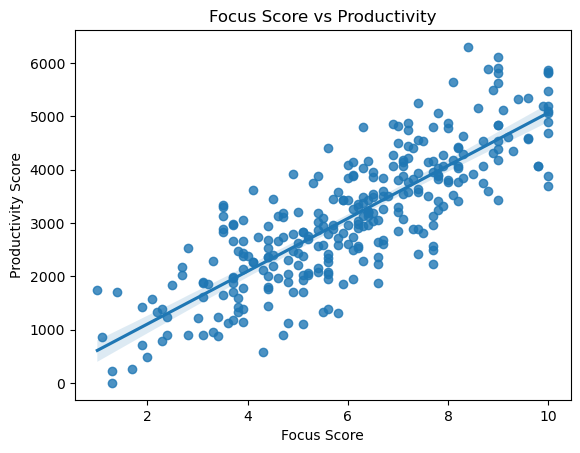

R² for FocusScore: 0.6777


In [23]:
sns.regplot(data=df, x='FocusScore', y='ProductivityScore')
plt.title('Focus Score vs Productivity')
plt.xlabel('Focus Score')
plt.ylabel('Productivity Score')
plt.show()

r2_focus = r2_score(df['ProductivityScore'], 
                    LinearRegression().fit(df[['FocusScore']], 
                    df['ProductivityScore']).predict(df[['FocusScore']]))
print(f'R² for FocusScore: {r2_focus:.4f}')

Compare All 3

R² Comparison:
YearsAtCompany: {r2_years:.4f}
HoursWorked:    {r2_hours:.4f}
FocusScore:     {r2_focus:.4f}

The feature with the strongest linear relationship with productivity is the one 
with the highest R² value.

TeamMeetingsPerWeek:

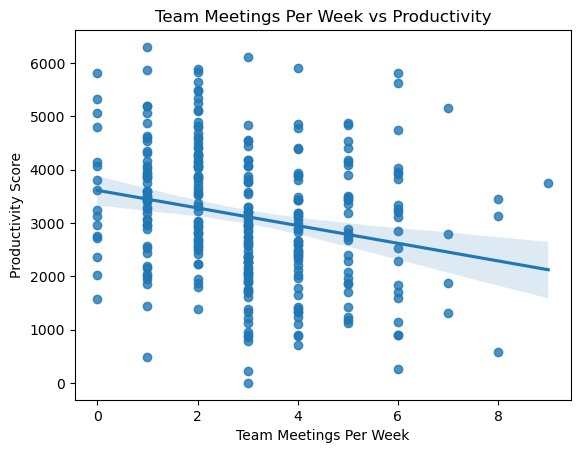

R² for TeamMeetingsPerWeek: 0.0542


In [24]:
sns.regplot(data=df, x='TeamMeetingsPerWeek', y='ProductivityScore')
plt.title('Team Meetings Per Week vs Productivity')
plt.xlabel('Team Meetings Per Week')
plt.ylabel('Productivity Score')
plt.show()

r2_meetings = r2_score(df['ProductivityScore'],
                       LinearRegression().fit(df[['TeamMeetingsPerWeek']],
                       df['ProductivityScore']).predict(df[['TeamMeetingsPerWeek']]))
print(f'R² for TeamMeetingsPerWeek: {r2_meetings:.4f}')

DeskLocation (categorical → boxplot):

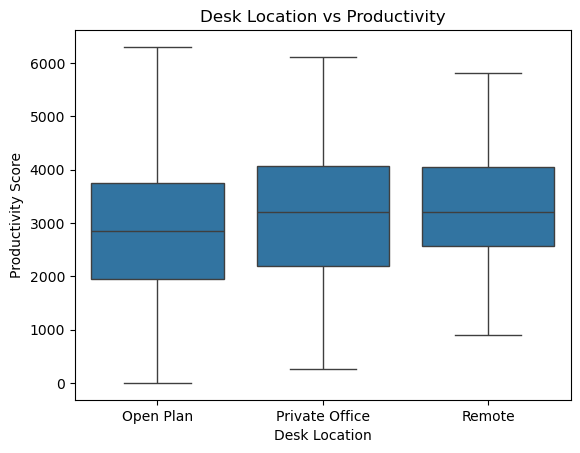

In [25]:
sns.boxplot(data=df, x='DeskLocation', y='ProductivityScore')
plt.title('Desk Location vs Productivity')
plt.xlabel('Desk Location')
plt.ylabel('Productivity Score')
plt.show()

Department (categorical → boxplot):

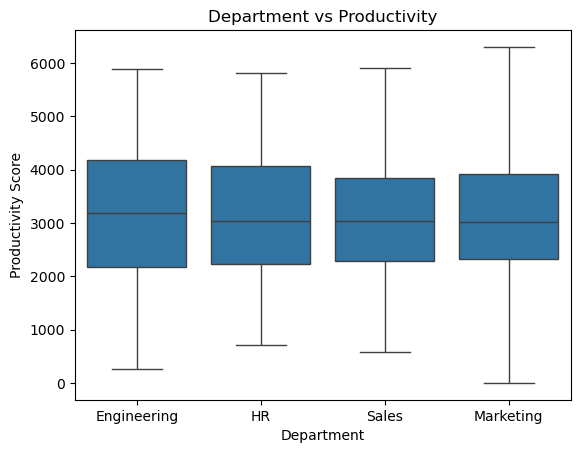

In [26]:
sns.boxplot(data=df, x='Department', y='ProductivityScore')
plt.title('Department vs Productivity')
plt.xlabel('Department')
plt.ylabel('Productivity Score')
plt.show()

## R² Summary

| Feature | R² Value | Relationship |
|---|---|---|
| FocusScore | 0.6777 | Strong positive — strongest predictor |
| TeamMeetingsPerWeek | 0.0542 | Weak negative relationship |
| HoursWorked | 0.0026 | No relationship |
| YearsAtCompany | 0.0004 | No relationship |

## Written Summary

The data shows that **FocusScore** is by far the strongest predictor of employee productivity (R²=0.6777), meaning employees who can focus better are significantly more productive. Years at the company and hours worked have virtually no relationship with productivity, which contradicts both the new and tenured employee complaints.

Team meetings per week show a weak negative relationship (R²=0.0542), suggesting that more meetings slightly reduce productivity. The desk location boxplots show that open plan workers tend to have lower median productivity compared to private office and remote workers, supporting the complaint about open plan distractions. Department does not appear to impact productivity meaningfully.

## Recommendations

1. **Focus is everything** — help employees protect their focus time.
2. **Reduce unnecessary team meetings** — they slightly hurt productivity.
3. **Consider moving employees out of open plan seating** into private offices or allowing remote work, as both show higher productivity.
4. **Do not judge employees by years of experience or hours worked** — neither predicts productivity in this dataset.